# Leaf Disease Segmentation
Source: https://universe.roboflow.com/xfhor-guq8a/leaf-disease-segmentation-yguau

> The dataset includes 1468 images.
> Leaf-Diseases are annotated in COCO Segmentation format.
> 
> The following pre-processing was applied to each image:
> * Auto-orientation of pixel data (with EXIF-orientation stripping)
> * Resize to 640x640 (Stretch)
> 
> The following augmentation was applied to create 3 versions of each source image:
> * 50% probability of horizontal flip
> * Randomly crop between 0 and 20 percent of the image
> * Random rotation of between -15 and +15 degrees
> * Random Gaussian blur of between 0 and 1.5 pixels

The dataset contains only sick plants - so data from plant net may be used as a healthy examples.


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as snb
import os
from pathlib import Path
import json

if os.path.abspath(os.curdir)[-2:] != "ai":
    os.chdir("..")

data_dir = Path(os.path.abspath(os.curdir) + "/data/leaf_disease")
train_dir = data_dir / "train"
test_dir = data_dir / "test"
valid_dir = data_dir / "valid"

with train_dir.joinpath("_annotations.coco.json").open(encoding='utf-8') as f:
    metadata_d = json.load(f)
    
metadata_d.keys()

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

In [15]:
metadata_d["images"][:2]

[{'id': 0,
  'license': 1,
  'file_name': '00373_png.rf.ec165600364249ee755a9396c584cf57.jpg',
  'height': 640,
  'width': 640,
  'date_captured': '2023-10-25T16:43:56+00:00'},
 {'id': 1,
  'license': 1,
  'file_name': '00180_png.rf.ec8552550862ad4980e5090fbc428960.jpg',
  'height': 640,
  'width': 640,
  'date_captured': '2023-10-25T16:43:56+00:00'}]

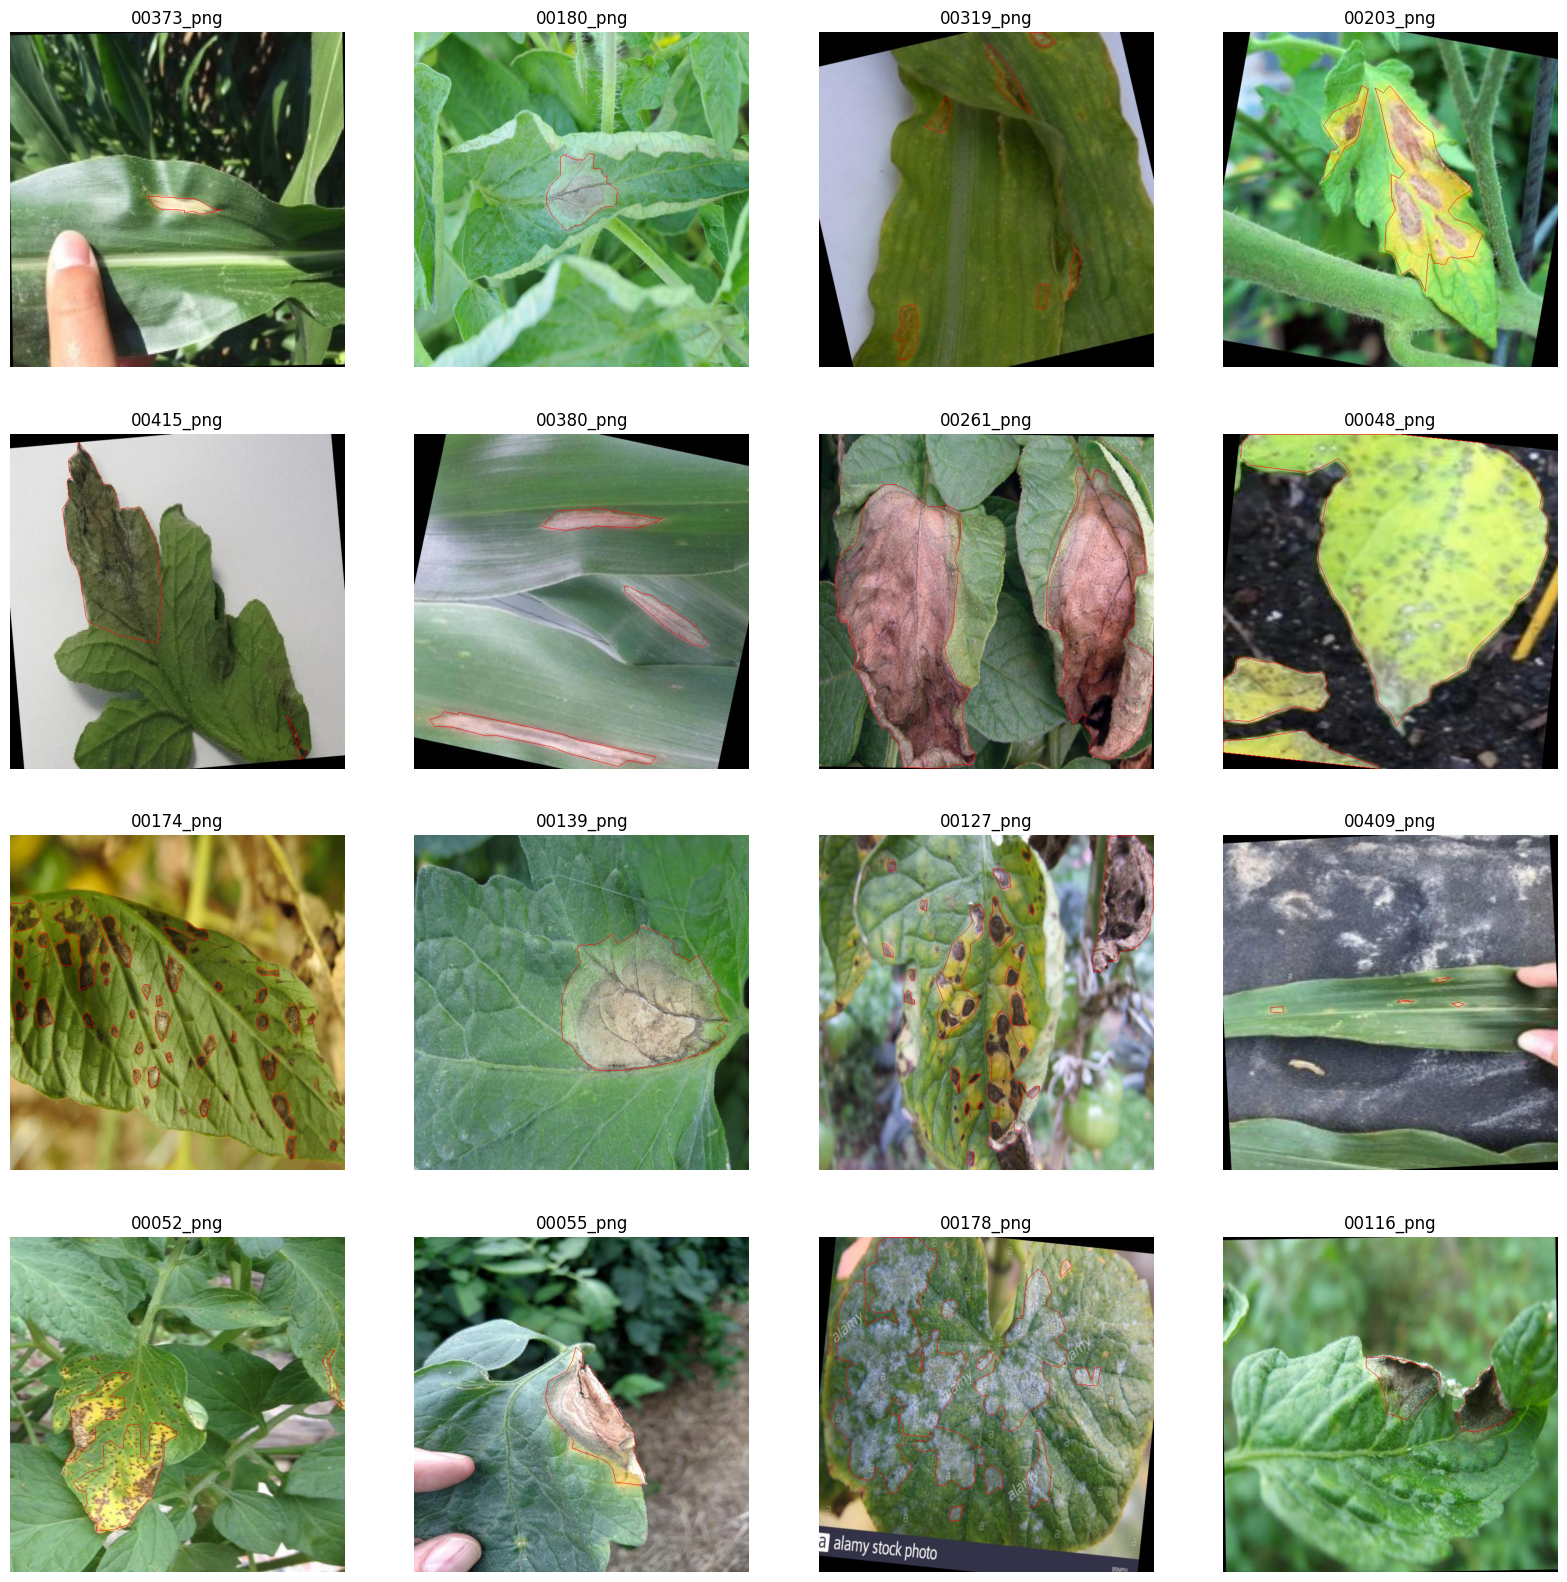

In [113]:
from PIL import Image, ImageDraw

siz = 4

fig, axes = plt.subplots(siz, siz, figsize=(20, 20))
annotations = metadata_d["annotations"]


for n, data in enumerate(metadata_d["images"]):
    ax = axes[n // siz, n % siz]

    img = Image.open(train_dir / data['file_name']).convert('RGBA')
    
    for ann in annotations:
        if ann['image_id'] == n:
            segm = ann['segmentation'][0]
            ImageDraw.Draw(img).polygon(segm, outline=(255, 0,0))

        if ann['image_id'] > n:
            break

    ax.imshow(img)
    ax.set_title(data['file_name'][:9])
    ax.axis('off')
    
    if n == siz * siz - 1:
        break

In [ ]:
# brak klasyfikacji do poszczególnych typów chorób, ani gatunków róślin
# zatem narazie jest tylko opcja klasyfikacji binarnej: roślina chora/zdrowa
# leaf disease ma tylko zbiór z roślinami chorymi (liście), jako zbiór z roślinami zdrowymi użyć możemy części plantnetu
